# Multi-Asset Portfolio Construction & Risk Analysis
Ryan Lemon | October 2026

A retrospective comparison of growth, drawdowns and costs. Read the memo and README for the mandate and limitations. Reserved evaluation: January 2023-September 2026. No claims of prospective performance.


In [1]:
from pathlib import Path
import sys, json, pandas as pd, numpy as np
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'inputs/portfolio/research.py').exists())
sys.path.insert(0, str(ROOT/'inputs/portfolio'))
import research
daily, monthly, asset_returns, audit = research.load_prices()
CELL_OUTPUT = [{'output_type':'stream','name':'stdout','text':f'{len(daily)} daily observations; {len(asset_returns)} monthly returns; missing={int(daily.isna().sum().sum())}\n'}]


5492 daily observations; 261 monthly returns; missing=0


## Rules and calculations
Quarterly rebalancing; 36 prior monthly returns; covariance shrinkage 20% toward its diagonal; 5 bps on purchases plus sales. Weights drift between trades. Minimum volatility has 40-65% equities. SHY is a Treasury proxy, not cash. The implementation below imports the accompanying, inspectable research.py rather than hiding the backtest.


In [2]:
portfolios = {m: research.backtest(asset_returns,m) for m in research.METHODS}
summary = pd.DataFrame({m:research.metrics(f,asset_returns.SHY) for m,(f,w) in portfolios.items()}).T
CELL_OUTPUT = [{'output_type':'display_data','metadata':{},'data':{'text/plain':summary[['cagr','volatility','max_drawdown','annual_turnover']].to_string(),'text/html':summary[['cagr','volatility','max_drawdown','annual_turnover']].to_html(float_format=lambda x:f'{x:.2%}')}}]


,cagr,volatility,max_drawdown,annual_turnover
60/40 benchmark,8.26%,9.59%,-27.77%,7.52%
Diversified policy,7.56%,10.00%,-29.70%,8.00%
Minimum volatility,5.92%,6.87%,-18.06%,12.23%


## Reserved evaluation
Rules remain unchanged. Parameters update only from prior returns. This period was reserved within the build, but the study is retrospective and not a genuinely unseen live test.


In [3]:
reserved = pd.DataFrame({m:research.metrics(f.loc['2023-01-31':],asset_returns.SHY) for m,(f,w) in portfolios.items()}).T
CELL_OUTPUT = [{'output_type':'display_data','metadata':{},'data':{'text/plain':reserved[['cagr','volatility','max_drawdown']].to_string(),'text/html':reserved[['cagr','volatility','max_drawdown']].to_html(float_format=lambda x:f'{x:.2%}')}}]


,cagr,volatility,max_drawdown
60/40 benchmark,13.51%,9.21%,-7.30%
Diversified policy,15.03%,8.96%,-6.68%
Minimum volatility,11.71%,7.28%,-5.45%


## Wealth and drawdowns
Monthly drawdowns understate losses that occur between month-ends.


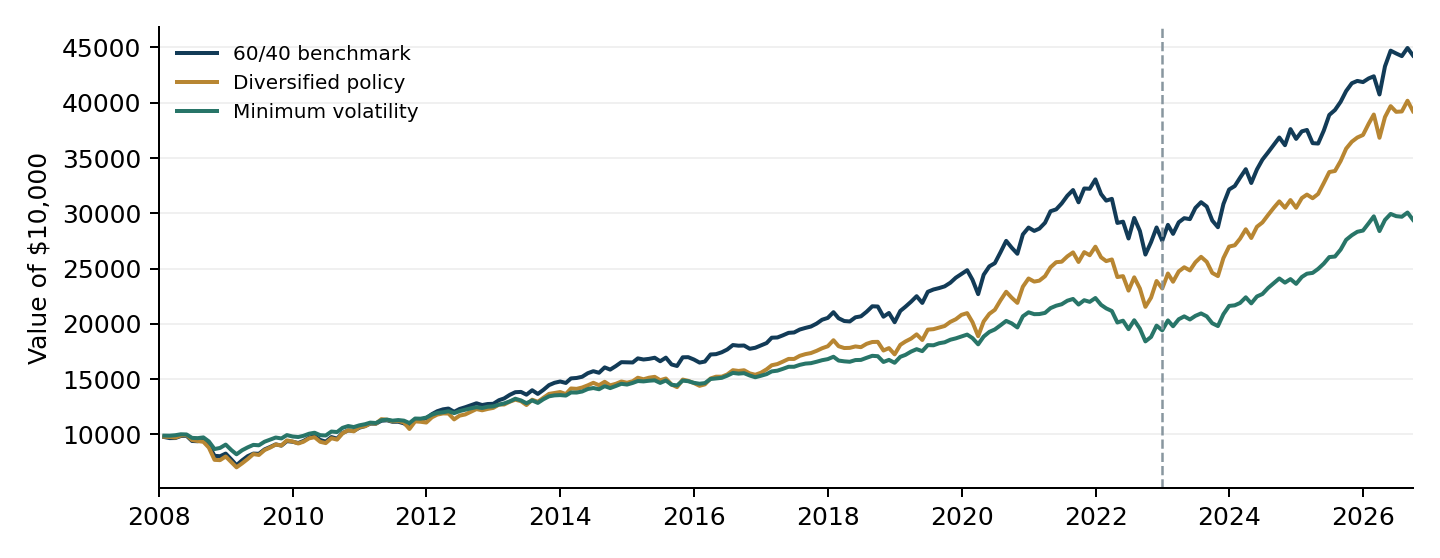

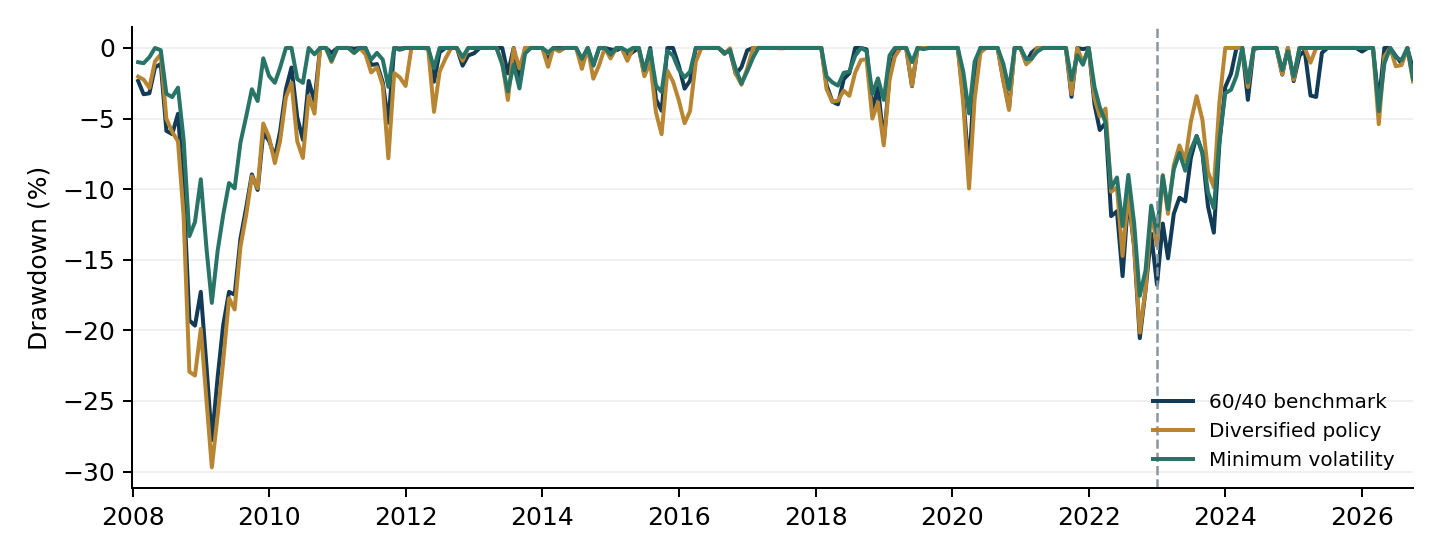

In [4]:
import base64
CELL_OUTPUT = [{'output_type':'display_data','metadata':{},'data':{'image/png':base64.b64encode((ROOT/'output/portfolio'/name).read_bytes()).decode(),'text/plain':name}} for name in ['wealth.png','drawdowns.png']]


## Historical stress windows
2008, 2020 and 2022 are calendar years; February-March 2020 isolates the monthly pandemic selloff. Return tables and figures are net of modeled costs.


In [5]:
results = json.loads((ROOT/'output/portfolio/research_results.json').read_text())
stress = pd.DataFrame({m:{event:s['total_return'] for event,s in results['stress'][m].items()} for m in research.METHODS})
CELL_OUTPUT = [{'output_type':'display_data','metadata':{},'data':{'text/plain':stress.to_string(),'text/html':stress.to_html(float_format=lambda x:f'{x:.2%}')}}]


,60/40 benchmark,Diversified policy,Minimum volatility
2008 financial crisis,-17.27%,-19.89%,-9.14%
2020 pandemic year,17.08%,15.79%,11.61%
2020 selloff,-8.71%,-9.95%,-4.64%
2022 rate shock,-16.77%,-14.01%,-13.09%


## Is the risk reduction mostly lower equity exposure?
The fixed control holds 30% SPY, 10% EFA, 40% IEF and 20% SHY. Its full-period volatility and drawdown closely resemble the optimizer. It is a diagnostic, not a fourth headline strategy.


In [6]:
research.TARGETS['40% equity control']=np.array([.3,.1,.4,0,.2])
control,_=research.backtest(asset_returns,'40% equity control')
comparison=pd.DataFrame({'Minimum volatility':research.metrics(portfolios['Minimum volatility'][0],asset_returns.SHY),'40% equity control':research.metrics(control,asset_returns.SHY)}).T
CELL_OUTPUT=[{'output_type':'display_data','metadata':{},'data':{'text/plain':comparison[['cagr','volatility','max_drawdown']].to_string(),'text/html':comparison[['cagr','volatility','max_drawdown']].to_html(float_format=lambda x:f'{x:.2%}')}}]


,cagr,volatility,max_drawdown
Minimum volatility,5.92%,6.87%,-18.06%
40% equity control,5.65%,6.79%,-17.91%


## Implementation costs and estimator sensitivity
The common start for 24/36/60-month windows is January 2010. These checks do not replace the primary specification. Risk contribution uses the same shrunk covariance matrix as the optimizer.


In [7]:
costs=pd.DataFrame(results['cost_sensitivity'])
lookbacks=pd.DataFrame(results['lookback_sensitivity']).T
CELL_OUTPUT=[{'output_type':'display_data','metadata':{},'data':{'text/plain':costs.to_string(),'text/html':costs.to_html(float_format=lambda x:f'{x:.2%}')}},{'output_type':'display_data','metadata':{},'data':{'text/plain':lookbacks[['cagr','volatility','max_drawdown']].to_string(),'text/html':lookbacks[['cagr','volatility','max_drawdown']].to_html(float_format=lambda x:f'{x:.2%}')}}]


,60/40 benchmark,Diversified policy,Minimum volatility
0,8.27%,7.57%,5.94%
5,8.26%,7.56%,5.92%
20,8.23%,7.53%,5.88%


,cagr,volatility,max_drawdown
24,6.94%,6.37%,-17.57%
36,6.77%,6.30%,-17.56%
60,6.41%,6.27%,-17.56%


In [8]:
for method,(f,w) in portfolios.items():
    prefix,_=research.backtest(asset_returns.loc[:'2022-12-31'],method)
    assert np.allclose(prefix.net_return,f.loc[:'2022-12-31'].net_return,atol=1e-12)
    assert np.allclose(w[research.ASSETS].sum(axis=1),1)
CELL_OUTPUT=[{'output_type':'stream','name':'stdout','text':'PASS: prefix invariance and weight sums; optimizer constraints checked at every rebalance.\n'+json.dumps(results['validation'],indent=2)}]


PASS: prefix invariance and weight sums; optimizer constraints checked at every rebalance.
{
  "prefix_invariance": "passed for all portfolios through 2022",
  "weight_and_constraint_checks": "passed",
  "independent_wealth_max_difference": 3.552713678800501e-15,
  "missing_prices": 0,
  "monthly_return_rows": 261
}

## Conclusion
The evidence favors a simple policy over unnecessary complexity. 60/40 offers stronger full-period growth; a lower-equity policy offers smaller drawdowns. The diversified allocation leads the reserved period but not the full sample. Minimum volatility is not proven superior to a fixed allocation with similar equity exposure.

Next steps: issuer NAV reconciliation, daily drawdowns, genuine prospective paper testing, broader assets and taxes.
